In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
housing = fetch_california_housing()
df=pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"]= housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
2

In [4]:
x= df[["MedInc", "HouseAge", "AveRooms", "AveOccup", "Latitude"]]
y= df["Price"]

In [5]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [6]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [8]:
y_pred = model.predict(x_test)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test, y_pred)
print("RMSE:",rmse)
print("R^2 Score:", r2)

RMSE: 0.8049810972472425
R^2 Score: 0.5055020396798211


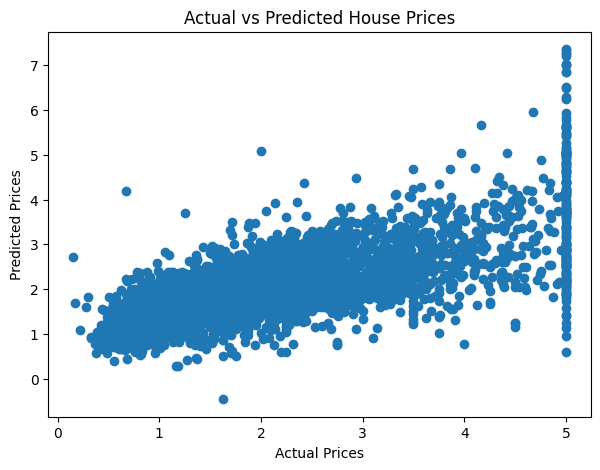

In [9]:
plt.figure(figsize=(7,5))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [10]:
coefficients= pd.DataFrame({"Feature": x.columns,"Coefficient": model.coef_})
print(coefficients)

    Feature  Coefficient
0    MedInc     0.439023
1  HouseAge     0.017017
2  AveRooms    -0.022090
3  AveOccup    -0.004067
4  Latitude    -0.045084


The R² score tells us how well the model predicts house prices. A value closer to 1 means the model makes more accurate predictions, while a value closer to 0 means it does not explain the prices very well. In this case, an R² score of 0.51 (0.5055) means the model explains about 50.6% of the variation in house prices, with a Root Mean Squared Error (RMSE) of 0.805. This shows the model performs reasonably well, but there is still substantial room for improvement.